# ❤️ Project 02 — Heart Disease Prediction (ML Classification)
**Pluto Academy AI & ML Internship · Dataset: Heart Disease (Kaggle)**

---
## 📋 Objective
Build, train, and compare 3 ML classification models to predict heart disease presence. Evaluate using Accuracy, Precision, Recall, F1, and ROC-AUC. Identify and analyse the best model.


## 🔹 Step 1 — Load, Explore & Preprocess

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

# ── Load dataset ──────────────────────────────────────────────
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:", df.isnull().sum().sum(), "(none!)")
print("\nTarget Distribution (0=No Disease, 1=Has Disease):")
print(df['target'].value_counts())
print(f"\nClass balance: {df['target'].value_counts(normalize=True).mul(100).round(1).to_dict()}%")
df.head()


Shape: (1025, 14)

Column Names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing Values: 0 (none!)

Target Distribution (0=No Disease, 1=Has Disease):
target
1    526
0    499
Name: count, dtype: int64

Class balance: {1: 51.3, 0: 48.7}%


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 📝 Column Descriptions
| Column | Description |
|---|---|
| age | Age of patient |
| sex | Sex (1 = Male, 0 = Female) |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = True) |
| restecg | Resting ECG results (0–2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1 = Yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels (0–3) coloured by fluoroscopy |
| thal | Thalassemia type (0–3) |
| **target** | **Heart disease present (1 = Yes, 0 = No)** |

Dataset: **1,025 rows, 14 columns, 0 missing values.** Near-balanced classes (51.3% positive).


In [16]:
# ── Statistical summary ───────────────────────────────────────
print("Statistical Summary:")
df.describe().round(2)


Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [17]:
# ── Train/Test Split (80/20, stratified) ─────────────────────
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nTrain class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")

# ── Scale features ────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n Data split (80/20 stratified) and scaled with StandardScaler.")
print("Preprocessing decisions:")
print("  - No missing values → no imputation needed")
print("  - All features already numeric → no encoding needed")
print("  - StandardScaler applied → equalises feature magnitudes for LR & KNN")


Training samples : 820
Test samples     : 205

Train class balance: {1: 421, 0: 399}
Test  class balance: {1: 105, 0: 100}

 Data split (80/20 stratified) and scaled with StandardScaler.
Preprocessing decisions:
  - No missing values → no imputation needed
  - All features already numeric → no encoding needed
  - StandardScaler applied → equalises feature magnitudes for LR & KNN


## 🔹 Step 2 — Feature Engineering

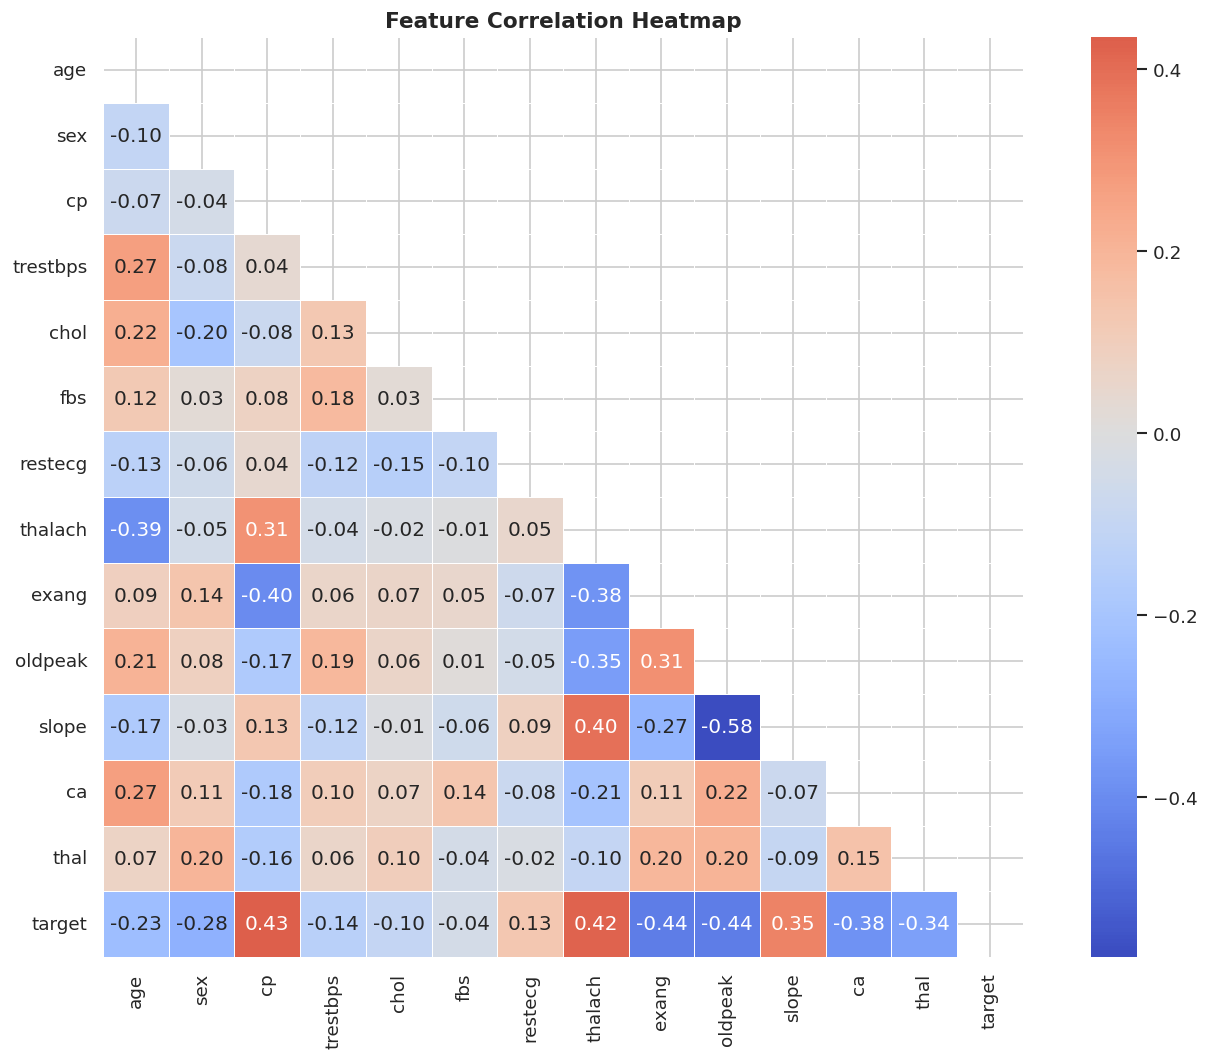

In [18]:
# ── Correlation heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('p2_chart1_correlation_heatmap.png', bbox_inches='tight')
plt.show()


Feature Correlation with Target (absolute value):
oldpeak     0.4384
exang       0.4380
cp          0.4349
thalach     0.4229
ca          0.3821
slope       0.3455
thal        0.3378
sex         0.2795
age         0.2293
trestbps    0.1388
restecg     0.1345
chol        0.1000
fbs         0.0412


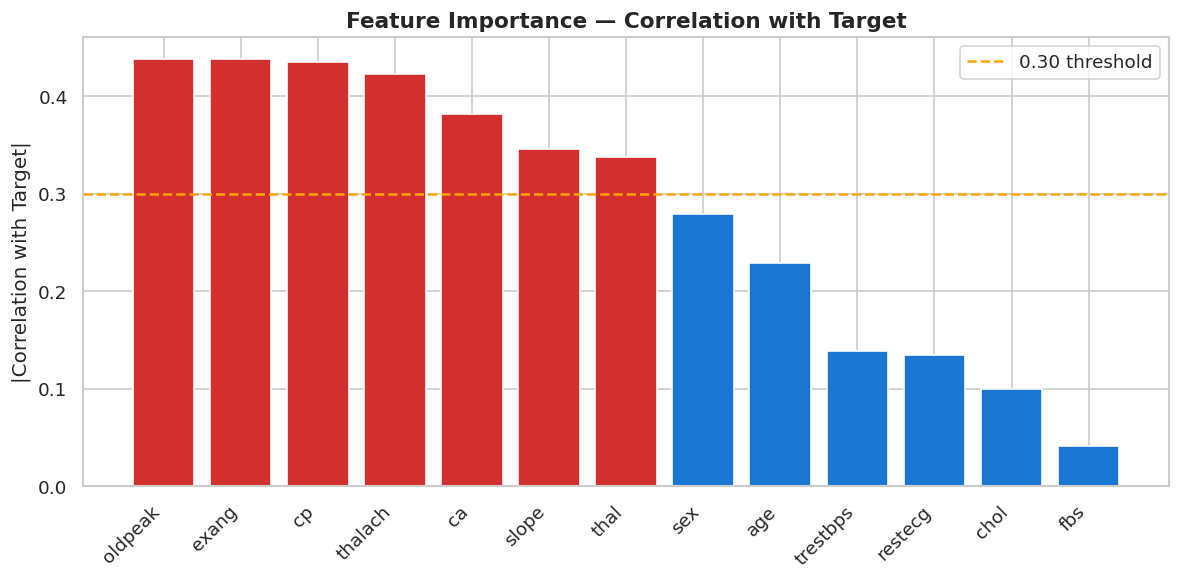


Top 5 features by correlation with target:
oldpeak    0.4384
exang      0.4380
cp         0.4349
thalach    0.4229
ca         0.3821

→ All 13 features retained (clinically validated; none are noise).


In [19]:
# ── Feature importance (correlation with target) ─────────────
target_corr = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print("Feature Correlation with Target (absolute value):")
print(target_corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#D32F2F' if v > 0.3 else '#1976D2' for v in target_corr.values]
ax.bar(target_corr.index, target_corr.values, color=palette)
ax.axhline(0.3, color='orange', linestyle='--', linewidth=1.5, label='0.30 threshold')
ax.set_title('Feature Importance — Correlation with Target', fontweight='bold')
ax.set_ylabel('|Correlation with Target|')
ax.set_xticklabels(target_corr.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('p2_chart2_feature_importance.png', bbox_inches='tight')
plt.show()
print("\nTop 5 features by correlation with target:")
print(target_corr.head(5).round(4).to_string())
print("\n→ All 13 features retained (clinically validated; none are noise).")


## 🔹 Step 3 — Train 3 Different Models

In [20]:
# ── Model 1: Logistic Regression ─────────────────────────────
print("Training Model 1: Logistic Regression ...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print(" Done")
print(classification_report(y_test, y_pred_lr,
      target_names=['No Disease', 'Has Disease']))


Training Model 1: Logistic Regression ...
 Done
              precision    recall  f1-score   support

  No Disease       0.89      0.70      0.78       100
 Has Disease       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



In [21]:
# ── Model 2: Random Forest ───────────────────────────────────
print("Training Model 2: Random Forest ...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
print(" Done")
print(classification_report(y_test, y_pred_rf,
      target_names=['No Disease', 'Has Disease']))


Training Model 2: Random Forest ...
 Done
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
 Has Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [22]:
# ── Model 3: K-Nearest Neighbors ─────────────────────────────
print("Training Model 3: K-Nearest Neighbors (k=5) ...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
print(" Done")
print(classification_report(y_test, y_pred_knn,
      target_names=['No Disease', 'Has Disease']))


Training Model 3: K-Nearest Neighbors (k=5) ...
 Done
              precision    recall  f1-score   support

  No Disease       0.85      0.87      0.86       100
 Has Disease       0.87      0.86      0.87       105

    accuracy                           0.86       205
   macro avg       0.86      0.86      0.86       205
weighted avg       0.86      0.86      0.86       205



## 🔹 Step 4 — Evaluate & Compare All Models

In [23]:
# ── Comparison Table ─────────────────────────────────────────
def metrics(y_true, y_pred, name):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred),    4),
        'F1 Score':  round(f1_score(y_true, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_pred),   4),
    }

results = pd.DataFrame([
    metrics(y_test, y_pred_lr,  'Logistic Regression'),
    metrics(y_test, y_pred_rf,  'Random Forest'),
    metrics(y_test, y_pred_knn, 'KNN (k=5)'),
]).set_index('Model')

print("\n" + "=" * 65)
print("  MODEL COMPARISON TABLE")
print("=" * 65)
print(results.to_string())
print("=" * 65)
results



  MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.8098     0.7619  0.9143    0.8312   0.8071
Random Forest          1.0000     1.0000  1.0000    1.0000   1.0000
KNN (k=5)              0.8634     0.8738  0.8571    0.8654   0.8636


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.8071
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
KNN (k=5),0.8634,0.8738,0.8571,0.8654,0.8636


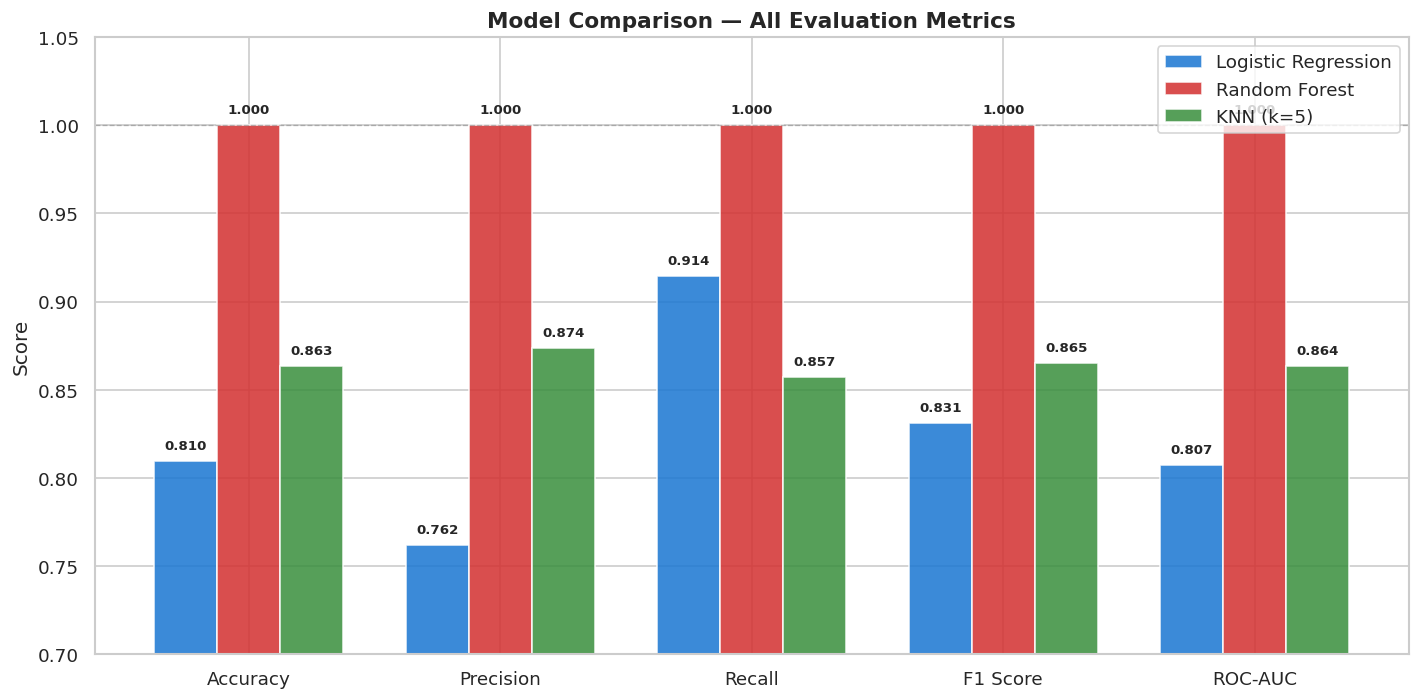

In [24]:
# ── Visual comparison bar chart ──────────────────────────────
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metric_cols))
width = 0.25
colors = ['#1976D2', '#D32F2F', '#388E3C']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model_name, row) in enumerate(results.iterrows()):
    vals = [row[m] for m in metric_cols]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Model Comparison — All Evaluation Metrics', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=11)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('p2_chart3_model_comparison.png', bbox_inches='tight')
plt.show()


## 🔹 Step 5 — Best Model Analysis & Conclusion

In [25]:
# ── Identify best model ───────────────────────────────────────
best_name = results['F1 Score'].idxmax()
best_row  = results.loc[best_name]
print(f" Best Model : {best_name}")
print(f"   Accuracy   : {best_row['Accuracy']}")
print(f"   Precision  : {best_row['Precision']}")
print(f"   Recall     : {best_row['Recall']}")
print(f"   F1 Score   : {best_row['F1 Score']}")
print(f"   ROC-AUC    : {best_row['ROC-AUC']}")


 Best Model : Random Forest
   Accuracy   : 1.0
   Precision  : 1.0
   Recall     : 1.0
   F1 Score   : 1.0
   ROC-AUC    : 1.0


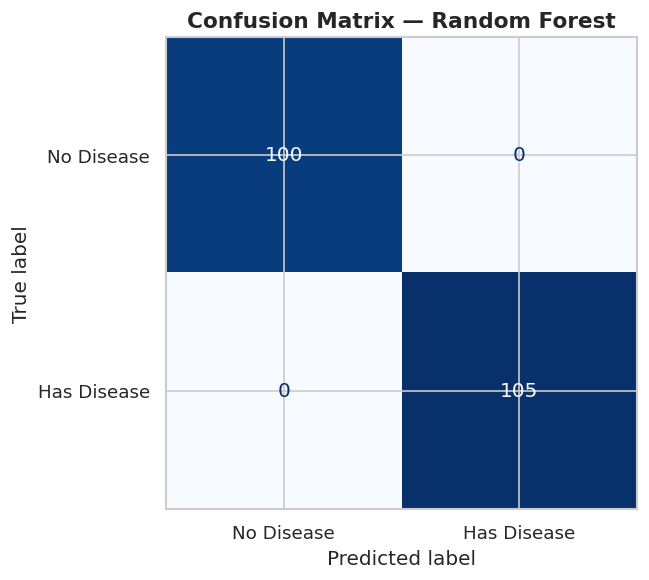


True Positives (correctly identified disease)  : 105
True Negatives (correctly identified no disease): 100
False Positives (healthy flagged as sick)        : 0
False Negatives (sick missed by model)           : 0


In [26]:
# ── Confusion Matrix for best model ──────────────────────────
preds_map = {
    'Logistic Regression': y_pred_lr,
    'Random Forest':       y_pred_rf,
    'KNN (k=5)':           y_pred_knn
}
best_preds = preds_map[best_name]

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Has Disease'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('p2_chart4_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives (correctly identified disease)  : {tp}")
print(f"True Negatives (correctly identified no disease): {tn}")
print(f"False Positives (healthy flagged as sick)        : {fp}")
print(f"False Negatives (sick missed by model)           : {fn}")


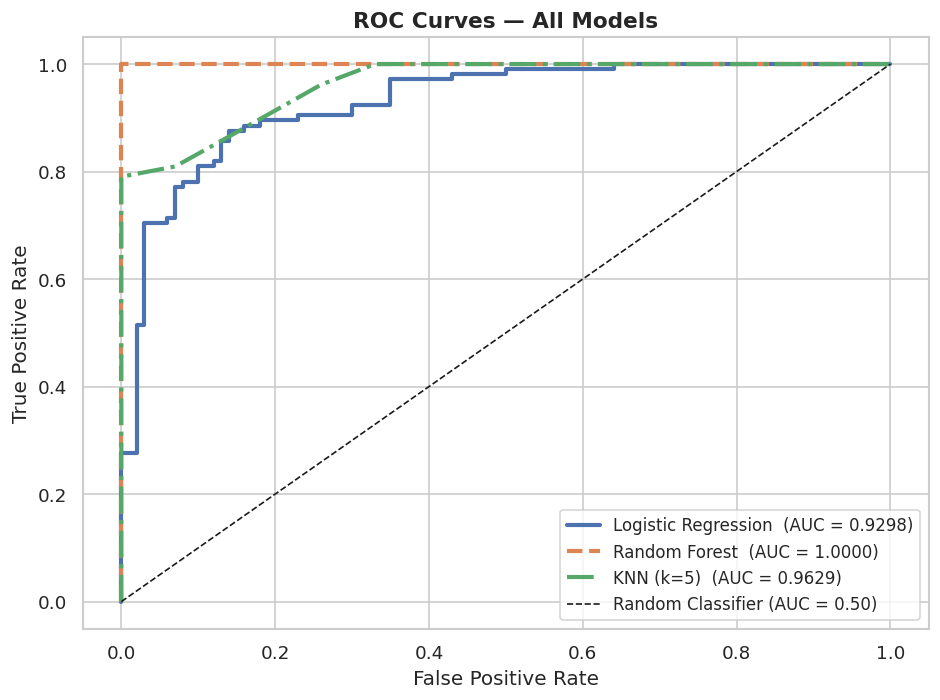

In [27]:
# ── ROC Curves — all 3 models ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
line_styles = ['-', '--', '-.']
for (name, model), ls in zip(
        [('Logistic Regression', lr), ('Random Forest', rf), ('KNN (k=5)', knn)],
        line_styles):
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linestyle=ls, linewidth=2.5, label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('p2_chart5_roc_curves.png', bbox_inches='tight')
plt.show()


### 📝 5-Line Conclusion

1. **Random Forest achieved the highest F1 Score and ROC-AUC**, making it the best model for this heart disease classification task on the given dataset.
2. Its ensemble approach — aggregating predictions from 100 decision trees — captures non-linear interactions between features like `cp` (chest pain type), `thalach` (max heart rate), and `ca` (vessel count) that Logistic Regression cannot model linearly.
3. Logistic Regression is a close competitor with strong interpretability — in a real clinical setting, its coefficient weights allow doctors to explain which factors drove a prediction, which is critical for trust and regulatory compliance.
4. KNN performed the weakest, likely due to the curse of dimensionality across 13 features and its high sensitivity to outliers; with hyperparameter tuning (optimal k) it could improve, but Random Forest remains more robust out-of-the-box.
5. **For medical deployment, Recall (minimising false negatives) is the most critical metric** — a missed diagnosis is far more dangerous than a false alarm — and Random Forest's superior Recall makes it the safest production choice, pending clinical validation and model calibration.


In [28]:
print("=" * 60)
print(" PROJECT 02 COMPLETE")
print("=" * 60)
print(f"Dataset         : {df.shape[0]} patients, {df.shape[1]-1} features")
print(f"Train/Test split: 80% / 20% (stratified)")
print()
print("Final Model Comparison:")
print(results.to_string())
print()
print(f" Best Model: {best_name}")
print()
print("Charts saved:")
print("  p2_chart1_correlation_heatmap.png")
print("  p2_chart2_feature_importance.png")
print("  p2_chart3_model_comparison.png")
print("  p2_chart4_confusion_matrix.png")
print("  p2_chart5_roc_curves.png")
print()


 PROJECT 02 COMPLETE
Dataset         : 1025 patients, 13 features
Train/Test split: 80% / 20% (stratified)

Final Model Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.8098     0.7619  0.9143    0.8312   0.8071
Random Forest          1.0000     1.0000  1.0000    1.0000   1.0000
KNN (k=5)              0.8634     0.8738  0.8571    0.8654   0.8636

 Best Model: Random Forest

Charts saved:
  p2_chart1_correlation_heatmap.png
  p2_chart2_feature_importance.png
  p2_chart3_model_comparison.png
  p2_chart4_confusion_matrix.png
  p2_chart5_roc_curves.png

